# Blackbody Colors Assignment

Calculate color indices (U-B, B-V, V-R, R-I) for blackbody temperatures from 3000K to 12000K in 200K increments using the Johnson-Cousins filter system.

## Theory

We assume all stars are perfect blackbodies with spectral energy distribution given by the Planck function:

$$F_\lambda(T) \propto \pi B_\lambda(T) = \frac{2\pi hc^2}{\lambda^5} \frac{1}{e^{hc/\lambda kT} - 1}$$

The magnitude in a filter is:

$$m = -2.5\log\left[\frac{\int S(\lambda)F_\lambda d\lambda}{\int S(\lambda)F_{\lambda,0} d\lambda}\right]$$

Where Vega (T=10,800K) is the zero-point reference star.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Physical constants
h = 6.62607015e-34  # Planck constant (J·s)
c = 2.99792458e8    # Speed of light (m/s)
k = 1.380649e-23    # Boltzmann constant (J/K)

# Vega effective temperature (reference star with m=0)
T_vega = 10800  # K

print("Constants loaded successfully")
print(f"Reference star (Vega) temperature: {T_vega} K")

Constants loaded successfully
Reference star (Vega) temperature: 10800 K


## Filter Specifications

Johnson-Cousins UBVRI filter system with box function approximations.

In [11]:
# Filter specifications (Johnson-Cousins UBVRI)
# Central wavelength and FWHM in nanometers
filters = {
    'U': {'center': 360e-9, 'fwhm': 70e-9},   # Convert to meters
    'B': {'center': 440e-9, 'fwhm': 100e-9},
    'V': {'center': 550e-9, 'fwhm': 90e-9},
    'R': {'center': 650e-9, 'fwhm': 100e-9},
    'I': {'center': 800e-9, 'fwhm': 150e-9},
}

# Display filter information
filter_df = pd.DataFrame([
    {'Filter': name, 
     'Central Wavelength (nm)': data['center']*1e9, 
     'FWHM (nm)': data['fwhm']*1e9}
    for name, data in filters.items()
])

print("Filter Specifications:")
print(filter_df.to_string(index=False))

Filter Specifications:
Filter  Central Wavelength (nm)  FWHM (nm)
     U                 360.0000    70.0000
     B                 440.0000   100.0000
     V                 550.0000    90.0000
     R                 650.0000   100.0000
     I                 800.0000   150.0000


## Function Definitions

In [12]:
def planck_function(wavelength, temperature):
    """
    Calculate the Planck function (blackbody spectral radiance).
    
    Parameters:
    -----------
    wavelength : float
        Wavelength in meters
    temperature : float
        Temperature in Kelvin
    
    Returns:
    --------
    float
        Spectral flux density (proportional to πB_λ(T))
    """
    # Avoid division by zero and overflow
    exponent = (h * c) / (wavelength * k * temperature)
    
    # Check if exponent is too large to avoid overflow
    if exponent > 700:
        return 0.0
    
    numerator = 2 * np.pi * h * c**2
    denominator = wavelength**5 * (np.exp(exponent) - 1)
    
    return numerator / denominator

def box_filter_sensitivity(wavelength, center, fwhm):
    """
    Box function filter sensitivity.
    Returns 1 if wavelength is within the filter band, 0 otherwise.
    """
    half_width = fwhm / 2
    if center - half_width <= wavelength <= center + half_width:
        return 1.0
    return 0.0

def calculate_magnitude(temperature, filter_name):
    """
    Calculate the magnitude in a given filter for a blackbody at given temperature.
    """
    center = filters[filter_name]['center']
    fwhm = filters[filter_name]['fwhm']
    
    # Define integration limits (filter bandpass)
    lambda_min = center - fwhm / 2
    lambda_max = center + fwhm / 2
    
    # Integrand for the object
    def integrand_object(wavelength):
        return box_filter_sensitivity(wavelength, center, fwhm) * planck_function(wavelength, temperature)
    
    # Integrand for Vega (reference star)
    def integrand_vega(wavelength):
        return box_filter_sensitivity(wavelength, center, fwhm) * planck_function(wavelength, T_vega)
    
    # Numerical integration
    flux_object, _ = quad(integrand_object, lambda_min, lambda_max, limit=100) # quad returns a tuple (result, error)
    flux_vega, _ = quad(integrand_vega, lambda_min, lambda_max, limit=100) 
    
    # Calculate magnitude using equation (2)
    magnitude = -2.5 * np.log10(flux_object / flux_vega) # Vega has m=0
    
    return magnitude

def calculate_color_indices(temperature):
    """
    Calculate all color indices for a given temperature.
    """
    # Calculate magnitudes in each filter
    m_U = calculate_magnitude(temperature, 'U')
    m_B = calculate_magnitude(temperature, 'B')
    m_V = calculate_magnitude(temperature, 'V')
    m_R = calculate_magnitude(temperature, 'R')
    m_I = calculate_magnitude(temperature, 'I')
    
    # Calculate color indices
    color_indices = {
        'U-B': m_U - m_B,
        'B-V': m_B - m_V,
        'V-R': m_V - m_R,
        'R-I': m_R - m_I
    }
    
    return color_indices

print("Functions defined successfully")

Functions defined successfully


## Calculate Color Indices

Calculate color indices for temperatures from 3000K to 12000K in 200K increments.

In [13]:
# Temperature range: 3000K to 12000K in 200K increments
temperatures = np.arange(3000, 12001, 200)

# Initialize results dictionary
results = {
    'T_eff (K)': [],
    'U-B': [],
    'B-V': [],
    'V-R': [],
    'R-I': []
}

print("Calculating color indices for blackbody temperatures...")
print("=" * 60)

# Calculate color indices for each temperature
for T in temperatures:
    print(f"Processing T = {T} K...")
    color_indices = calculate_color_indices(T)
    
    results['T_eff (K)'].append(T)
    results['U-B'].append(color_indices['U-B'])
    results['B-V'].append(color_indices['B-V'])
    results['V-R'].append(color_indices['V-R'])
    results['R-I'].append(color_indices['R-I'])

# Create DataFrame
df = pd.DataFrame(results)

print("\nCalculation complete")
print("=" * 60)

Calculating color indices for blackbody temperatures...
Processing T = 3000 K...
Processing T = 3200 K...
Processing T = 3400 K...
Processing T = 3600 K...
Processing T = 3800 K...
Processing T = 4000 K...
Processing T = 4200 K...
Processing T = 4400 K...
Processing T = 4600 K...
Processing T = 4800 K...
Processing T = 5000 K...
Processing T = 5200 K...
Processing T = 5400 K...
Processing T = 5600 K...
Processing T = 5800 K...
Processing T = 6000 K...
Processing T = 6200 K...
Processing T = 6400 K...
Processing T = 6600 K...
Processing T = 6800 K...
Processing T = 7000 K...
Processing T = 7200 K...
Processing T = 7400 K...
Processing T = 7600 K...
Processing T = 7800 K...
Processing T = 8000 K...
Processing T = 8200 K...
Processing T = 8400 K...
Processing T = 8600 K...
Processing T = 8800 K...
Processing T = 9000 K...
Processing T = 9200 K...
Processing T = 9400 K...
Processing T = 9600 K...
Processing T = 9800 K...
Processing T = 10000 K...
Processing T = 10200 K...
Processing T = 10

## Results Table

In [14]:
# Display the full table
print("COLOR INDICES TABLE")
print("=" * 70)
pd.options.display.float_format = '{:.4f}'.format
display(df)

COLOR INDICES TABLE


,T_eff (K),U-B,B-V,V-R,R-I
0,3000,1.8285,1.6221,0.9960,0.9959
1,3200,1.6687,1.4849,0.9073,0.9042
2,3400,1.5277,1.3629,0.8290,0.8236
3,3600,1.4023,1.2537,0.7593,0.7521
4,3800,1.2900,1.1553,0.6969,0.6885
5,4000,1.1890,1.0664,0.6408,0.6315
6,4200,1.0976,0.9856,0.5902,0.5802
7,4400,1.0145,0.9118,0.5442,0.5339
8,4600,0.9386,0.8443,0.5023,0.4918
9,4800,0.8691,0.7822,0.4640,0.4534


## Save Results to Files

In [15]:
# Save to CSV
csv_filename = 'blackbody_color_indices.csv'
df.to_csv(csv_filename, index=False, float_format='%.4f')
print(f"Table saved to {csv_filename}")

# Save to LaTeX
latex_filename = 'blackbody_color_indices.tex'
with open(latex_filename, 'w') as f:
    f.write(df.to_latex(index=False, float_format='%.4f'))
print(f"LaTeX table saved to {latex_filename}")

Table saved to blackbody_color_indices.csv
LaTeX table saved to blackbody_color_indices.tex


## Individual Plots for Each Color Index

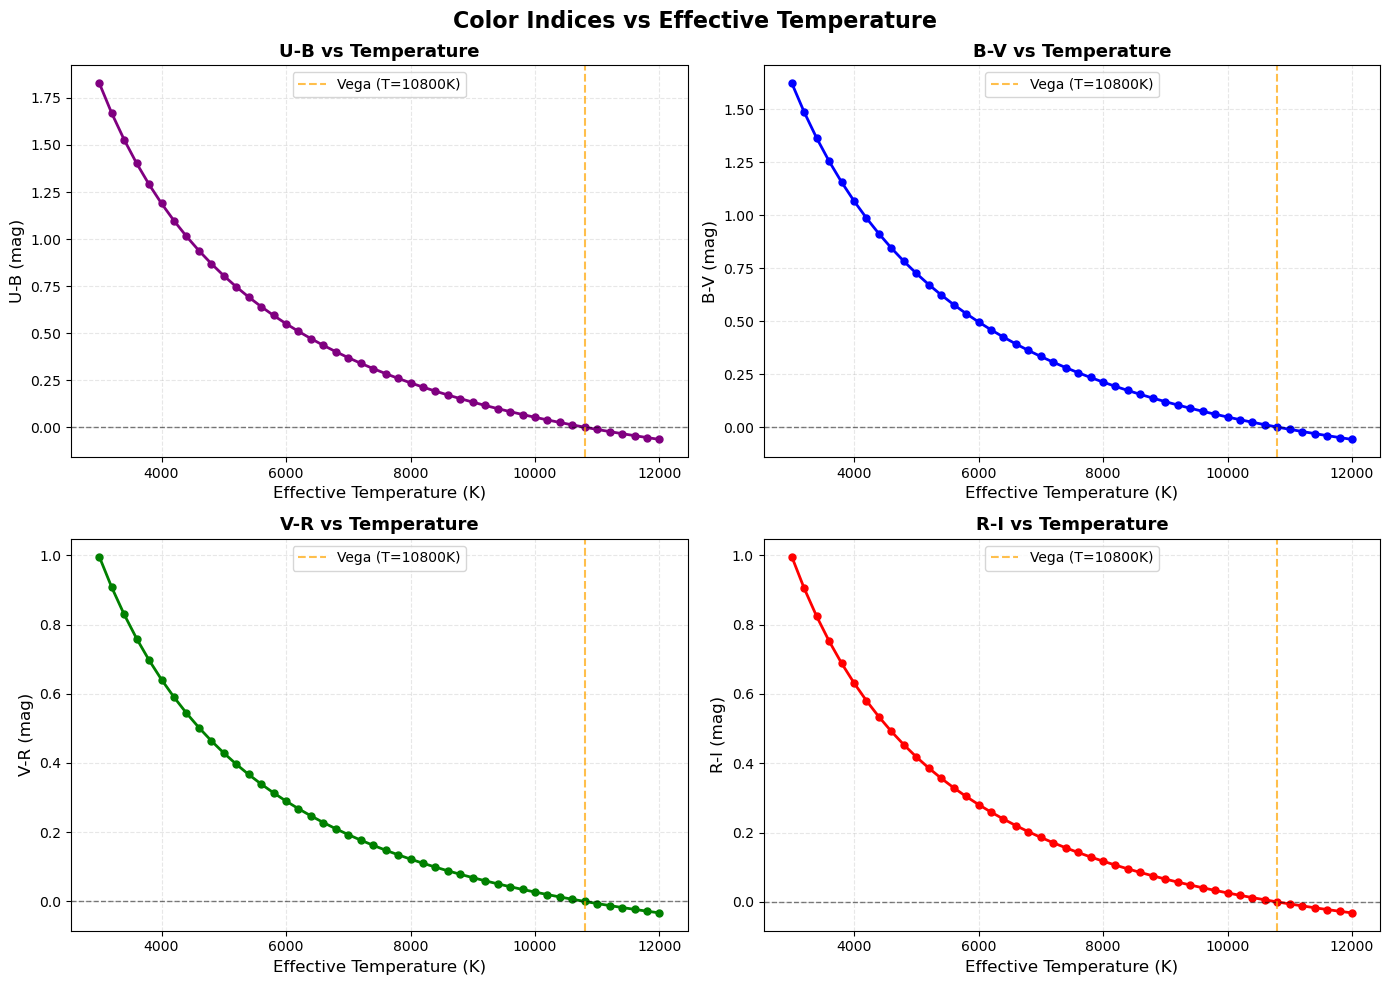

Individual plots saved to blackbody_color_indices_individual.png


In [16]:
# Create individual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Color Indices vs Effective Temperature', fontsize=16, fontweight='bold')

color_indices_list = ['U-B', 'B-V', 'V-R', 'R-I']
colors = ['purple', 'blue', 'green', 'red']

for i, (ax, color_index, color) in enumerate(zip(axes.flat, color_indices_list, colors)):
    ax.plot(results['T_eff (K)'], results[color_index],
            marker='o', linestyle='-', color=color, linewidth=2, markersize=5)
    ax.set_xlabel('Effective Temperature (K)', fontsize=12)
    ax.set_ylabel(f'{color_index} (mag)', fontsize=12)
    ax.set_title(f'{color_index} vs Temperature', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Mark Vega's temperature
    ax.axvline(x=T_vega, color='orange', linestyle='--', linewidth=1.5,
               alpha=0.7, label=f'Vega (T={T_vega}K)')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('blackbody_color_indices_individual.png', dpi=300, bbox_inches='tight')
plt.show()

print("Individual plots saved to blackbody_color_indices_individual.png")

## Combined Plot of All Color Indices

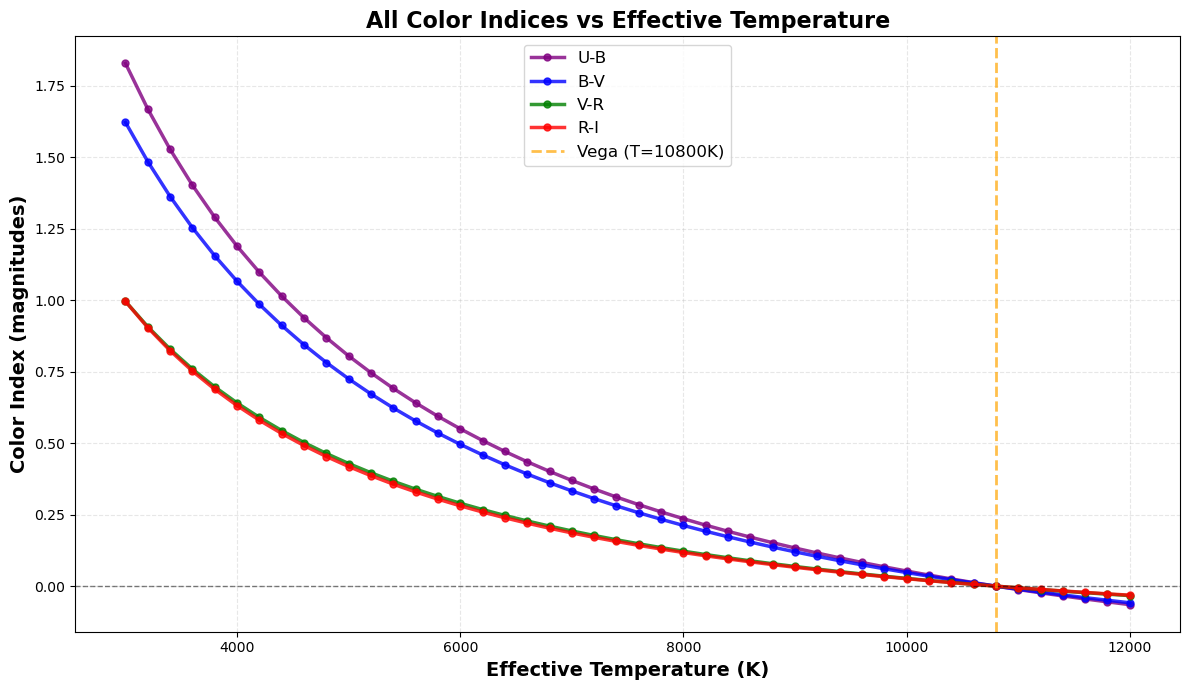

Combined plot saved to blackbody_color_indices_combined.png


In [17]:
# Create combined plot
plt.figure(figsize=(12, 7))

for color_index, color in zip(color_indices_list, colors):
    plt.plot(results['T_eff (K)'], results[color_index],
            marker='o', linestyle='-', color=color, linewidth=2.5,
            markersize=5, label=color_index, alpha=0.8)

plt.xlabel('Effective Temperature (K)', fontsize=14, fontweight='bold')
plt.ylabel('Color Index (magnitudes)', fontsize=14, fontweight='bold')
plt.title('All Color Indices vs Effective Temperature', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=T_vega, color='orange', linestyle='--', linewidth=2,
            alpha=0.7, label=f'Vega (T={T_vega}K)')
plt.legend(fontsize=12, loc='best')
plt.tight_layout()

plt.savefig('blackbody_color_indices_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("Combined plot saved to blackbody_color_indices_combined.png")

## Analysis and Observations

In [18]:
print("Key Observations:")
print("=" * 70)
print(f"\n1. At Vega's temperature ({T_vega}K), all color indices should be close to 0:")
vega_idx = list(temperatures).index(T_vega)
print(f"   U-B = {results['U-B'][vega_idx]:.4f}")
print(f"   B-V = {results['B-V'][vega_idx]:.4f}")
print(f"   V-R = {results['V-R'][vega_idx]:.4f}")
print(f"   R-I = {results['R-I'][vega_idx]:.4f}")

print(f"\n2. Coolest star (T={temperatures[0]}K):")
print(f"   U-B = {results['U-B'][0]:.4f}")
print(f"   B-V = {results['B-V'][0]:.4f}")
print(f"   V-R = {results['V-R'][0]:.4f}")
print(f"   R-I = {results['R-I'][0]:.4f}")
print("   (Positive values indicate redder colors)")

print(f"\n3. Hottest star (T={temperatures[-1]}K):")
print(f"   U-B = {results['U-B'][-1]:.4f}")
print(f"   B-V = {results['B-V'][-1]:.4f}")
print(f"   V-R = {results['V-R'][-1]:.4f}")
print(f"   R-I = {results['R-I'][-1]:.4f}")
print("   (Negative values indicate bluer colors)")

print("\n4. Color indices decrease (become more negative) with increasing temperature,")
print("   confirming that hotter stars are bluer and cooler stars are redder.")

Key Observations:

1. At Vega's temperature (10800K), all color indices should be close to 0:
   U-B = 0.0000
   B-V = 0.0000
   V-R = 0.0000
   R-I = 0.0000

2. Coolest star (T=3000K):
   U-B = 1.8285
   B-V = 1.6221
   V-R = 0.9960
   R-I = 0.9959
   (Positive values indicate redder colors)

3. Hottest star (T=12000K):
   U-B = -0.0648
   B-V = -0.0582
   V-R = -0.0331
   R-I = -0.0317
   (Negative values indicate bluer colors)

4. Color indices decrease (become more negative) with increasing temperature,
   confirming that hotter stars are bluer and cooler stars are redder.


## Summary

This notebook calculates color indices for blackbody stars using:
- The Planck function for blackbody spectral energy distribution
- Box function approximations for Johnson-Cousins UBVRI filters
- Vega (T=10,800K) as the zero-point reference
- Numerical integration to compute magnitudes

The results show the expected trend: cooler stars have positive (redder) color indices, while hotter stars have negative (bluer) color indices. At Vega's temperature, all color indices are approximately zero by definition.

Files generated:
- `blackbody_color_indices.csv` - Data table in CSV format
- `blackbody_color_indices.tex` - Data table in LaTeX format
- `blackbody_color_indices_individual.png` - Individual plots for each color index
- `blackbody_color_indices_combined.png` - Combined plot of all color indices